# Notebook 06: Billing Leakage & Revenue Recovery — HealthFirst Australia

**Project**: HealthFirst Australia — Revenue Intelligence Platform  
**Phase**: 06 — Billing Leakage Quantification & Recovery Scenarios  
**Date**: 2026-04-12

### Five Leakage Buckets
| # | Bucket | Source |
|---|--------|--------|
| 1 | Medicare claim rejections | `billing_claims` — claim_type=Medicare, status=rejected |
| 2 | Private insurance rejections / partials | `billing_claims` — claim_type=Private_Insurance, status in (rejected, partial) |
| 3 | No-show revenue loss | `appointments` — status=no_show, sum of scheduled_fee |
| 4 | Self-pay defaults / unpaid | `billing_claims` — claim_type=Self_Pay, status=unpaid |
| 5 | Bulk billing rate erosion (month 7+) | Estimated from bulk bill rate drop × appointment volume × avg fee |

---
## 0. Setup & Data Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

CLEAN_DIR   = '../data/cleaned'
PROC_DIR    = '../data/processed'
REPORTS_DIR = '../reports'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# Load datasets
appt   = pd.read_csv(f'{CLEAN_DIR}/appointments.csv', parse_dates=['appointment_date'])
claims = pd.read_csv(f'{CLEAN_DIR}/billing_claims.csv', parse_dates=['claim_date'])

# Normalise numeric fields
for col in ['scheduled_fee', 'billed_amount', 'staff_cost', 'medicare_rebate',
            'patient_gap', 'insurance_paid']:
    if col in appt.columns:
        appt[col] = pd.to_numeric(appt[col], errors='coerce').fillna(0)

for col in ['claimed_amount', 'approved_amount', 'rejected_amount']:
    if col in claims.columns:
        claims[col] = pd.to_numeric(claims[col], errors='coerce').fillna(0)

# Month labels
appt['month_str'] = appt['appointment_date'].dt.to_period('M').astype(str)
appt['month_num'] = (
    (appt['appointment_date'].dt.year - appt['appointment_date'].dt.year.min()) * 12
    + appt['appointment_date'].dt.month
)
min_month = appt['month_num'].min()
appt['month_num'] = appt['month_num'] - min_month + 1  # 1-indexed

claims['month_str'] = claims['claim_date'].dt.to_period('M').astype(str)

print(f'Appointments : {len(appt):,} rows')
print(f'Claims       : {len(claims):,} rows')
print(f'\nAppointment statuses: {appt["status"].value_counts().to_dict()}')
print(f'Claim types         : {claims["claim_type"].value_counts().to_dict()}')
print(f'Claim statuses      : {claims["claim_status"].value_counts().to_dict()}')

Appointments : 20,000 rows
Claims       : 11,094 rows

Appointment statuses: {'completed': 11094, 'no_show': 3293, 'rescheduled': 2824, 'cancelled': 2789}
Claim types         : {'Medicare': 4231, 'Private_Insurance': 3746, 'Self_Pay': 3117}
Claim statuses      : {'approved': 7237, 'paid': 2758, 'rejected': 558, 'unpaid': 359, 'partial': 182}


---
## 1. Gross Revenue Baseline

In [5]:
completed = appt[appt['status'] == 'completed']
gross_revenue = completed['billed_amount'].sum()

# Cross-check: total scheduled fees across all appointments
total_scheduled = appt['scheduled_fee'].sum()

print(f'Gross Revenue (completed, billed_amount)  : ${gross_revenue:>14,.2f}')
print(f'Total Scheduled Fees (all appointments)   : ${total_scheduled:>14,.2f}')
print(f'Total Claims (claimed_amount)             : ${claims["claimed_amount"].sum():>14,.2f}')

Gross Revenue (completed, billed_amount)  : $  1,547,162.07
Total Scheduled Fees (all appointments)   : $  1,823,908.90
Total Claims (claimed_amount)             : $  1,137,607.87


---
## 2. Five Leakage Buckets

In [7]:
# ── Bucket 1: Medicare Claim Rejections ──
b1_mask = (
    (claims['claim_type'].str.lower().str.strip() == 'medicare') &
    (claims['claim_status'].str.lower().str.strip() == 'rejected')
)
b1_claims = claims[b1_mask]
bucket1   = b1_claims['rejected_amount'].sum()
print(f'Bucket 1 — Medicare Rejections         : ${bucket1:>12,.2f}  ({len(b1_claims):,} claims)')

# ── Bucket 2: Private Insurance Rejections / Partials ──
b2_mask = (
    (claims['claim_type'].str.lower().str.strip().isin(['private_insurance', 'private insurance', 'private'])) &
    (claims['claim_status'].str.lower().str.strip().isin(['rejected', 'partial']))
)
b2_claims = claims[b2_mask]
bucket2   = b2_claims['rejected_amount'].sum()
print(f'Bucket 2 — Private Insurance Reject/Partial: ${bucket2:>12,.2f}  ({len(b2_claims):,} claims)')

# ── Bucket 3: No-Show Revenue Loss ──
no_show_appts = appt[appt['status'] == 'no_show']
bucket3       = no_show_appts['scheduled_fee'].sum()
print(f'Bucket 3 — No-Show Revenue Loss        : ${bucket3:>12,.2f}  ({len(no_show_appts):,} appts)')

# ── Bucket 4: Self-Pay Defaults / Unpaid ──
b4_mask = (
    (claims['claim_type'].str.lower().str.strip().isin(['self_pay', 'self pay', 'selfpay'])) &
    (claims['claim_status'].str.lower().str.strip() == 'unpaid')
)
b4_claims = claims[b4_mask]
bucket4   = b4_claims['claimed_amount'].sum()
print(f'Bucket 4 — Self-Pay Defaults (Unpaid)  : ${bucket4:>12,.2f}  ({len(b4_claims):,} claims)')

# ── Bucket 5: Bulk Billing Rate Erosion (Month 7+) ──
appt_completed = appt[appt['status'] == 'completed'].copy()
# Determine if this appointment was bulk_bill
if 'billing_type' in appt_completed.columns:
    appt_completed['is_bulk'] = appt_completed['billing_type'].str.lower().str.strip() == 'bulk_bill'
elif 'claim_type' in appt_completed.columns:
    appt_completed['is_bulk'] = appt_completed['claim_type'].str.lower().str.strip() == 'bulk_bill'
else:
    appt_completed['is_bulk'] = False

early = appt_completed[appt_completed['month_num'] <= 6]
late  = appt_completed[appt_completed['month_num'] >= 7]

rate_early = early['is_bulk'].mean() if len(early) > 0 else 0
rate_late  = late['is_bulk'].mean()  if len(late)  > 0 else 0
avg_fee    = appt_completed['scheduled_fee'].mean()

# Revenue lost because fewer appointments were bulk-billed at lower (bulk) rate
# In Australia, bulk-bill typically means no patient gap — but here we estimate
# the notional revenue erosion from shifting away from bulk billing
# Proxy: rate drop × late-period volume × avg_fee × estimated gap factor (30%)
rate_drop    = max(rate_early - rate_late, 0)
bucket5_raw  = rate_drop * len(late) * avg_fee
# Conservative: apply 30% revenue impact factor (bulk bill cap vs private billing)
bucket5      = bucket5_raw * 0.30

print(f'\nBulk billing rate M1–6 : {rate_early*100:.1f}%')
print(f'Bulk billing rate M7+  : {rate_late*100:.1f}%')
print(f'Rate drop              : {rate_drop*100:.1f} pp')
print(f'Late-period appointments: {len(late):,}')
print(f'Avg scheduled fee       : ${avg_fee:,.2f}')
print(f'Bucket 5 — Bulk Bill Erosion (est.)    : ${bucket5:>12,.2f}')

# ── Summary Table ──
buckets = {
    'Bucket 1: Medicare Rejections':        bucket1,
    'Bucket 2: Private Ins. Reject/Partial': bucket2,
    'Bucket 3: No-Show Loss':               bucket3,
    'Bucket 4: Self-Pay Defaults':          bucket4,
    'Bucket 5: Bulk Bill Erosion':          bucket5,
}

total_leakage = sum(buckets.values())
realized      = gross_revenue - total_leakage

leakage_df = pd.DataFrame([
    {'bucket': k, 'leakage_amount': v,
     'pct_of_gross': v / gross_revenue * 100 if gross_revenue > 0 else 0}
    for k, v in buckets.items()
])
leakage_df = leakage_df.sort_values('leakage_amount', ascending=False).reset_index(drop=True)

print('\n=== LEAKAGE SUMMARY ===')
print(leakage_df.to_string(index=False))
print(f'\nTotal Leakage    : ${total_leakage:,.2f}  ({total_leakage/gross_revenue*100:.1f}% of gross)')
print(f'Gross Revenue    : ${gross_revenue:,.2f}')
print(f'Realized Revenue : ${realized:,.2f}')

Bucket 1 — Medicare Rejections         : $   21,662.05  (253 claims)
Bucket 2 — Private Insurance Reject/Partial: $   43,674.14  (487 claims)
Bucket 3 — No-Show Revenue Loss        : $  298,799.25  (3,293 appts)
Bucket 4 — Self-Pay Defaults (Unpaid)  : $   42,370.92  (359 claims)

Bulk billing rate M1–6 : 40.8%
Bulk billing rate M7+  : 37.1%
Rate drop              : 3.7 pp
Late-period appointments: 8,004
Avg scheduled fee       : $91.39
Bucket 5 — Bulk Bill Erosion (est.)    : $    8,125.08

=== LEAKAGE SUMMARY ===
                               bucket  leakage_amount  pct_of_gross
               Bucket 3: No-Show Loss      298,799.25         19.31
Bucket 2: Private Ins. Reject/Partial       43,674.14          2.82
          Bucket 4: Self-Pay Defaults       42,370.92          2.74
        Bucket 1: Medicare Rejections       21,662.05          1.40
          Bucket 5: Bulk Bill Erosion        8,125.08          0.53

Total Leakage    : $414,631.44  (26.8% of gross)
Gross Revenue    : $1

---
## 3. Waterfall Chart: Gross Revenue → Realized Revenue

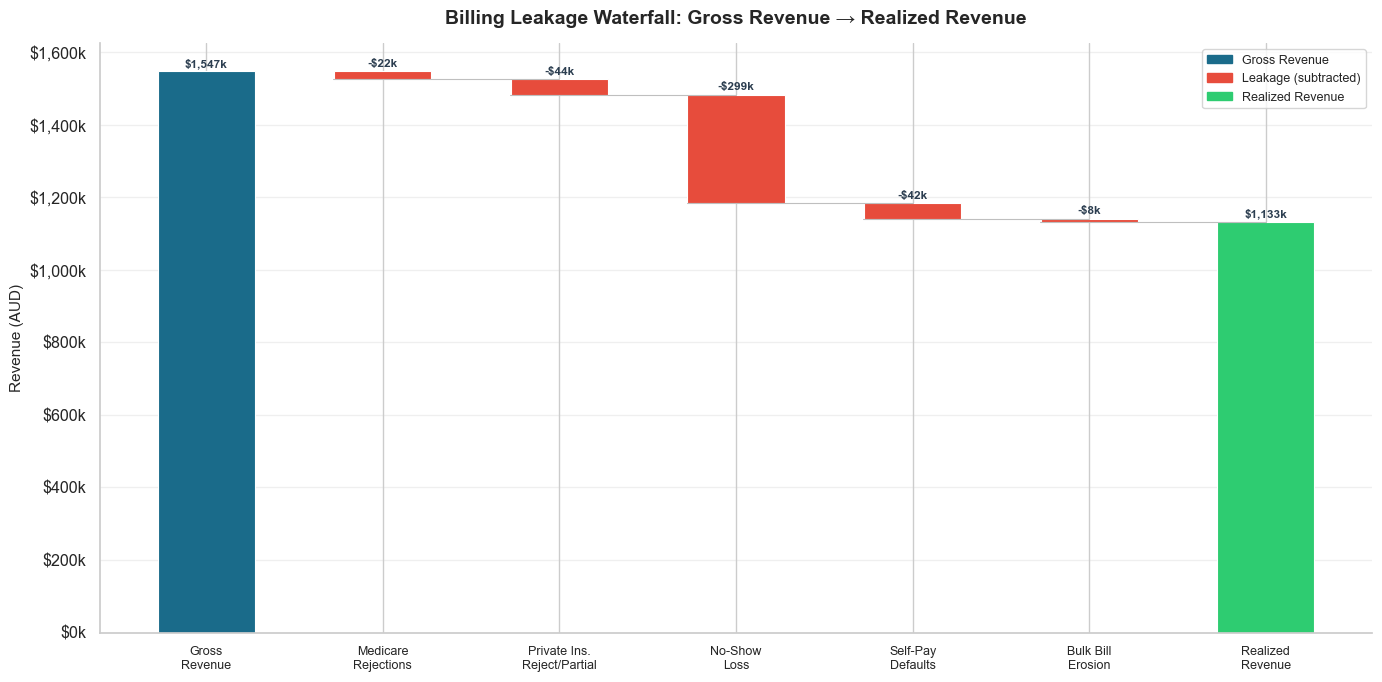

Saved: reports/billing_leakage_waterfall.png


In [9]:
# Build waterfall data
wf_labels  = ['Gross Revenue'] + list(buckets.keys()) + ['Realized Revenue']
wf_amounts = [gross_revenue] + [-v for v in buckets.values()] + [realized]

running = 0
bottoms = []
heights = []
colors  = []

for i, (lbl, amt) in enumerate(zip(wf_labels, wf_amounts)):
    if i == 0:
        bottoms.append(0)
        heights.append(amt)
        colors.append('#1a6b8a')
        running = amt
    elif i == len(wf_labels) - 1:
        bottoms.append(0)
        heights.append(realized)
        colors.append('#2ecc71')
    else:
        running += amt  # amt is negative here
        bottoms.append(running)
        heights.append(-amt)  # positive bar height
        colors.append('#e74c3c')

fig, ax = plt.subplots(figsize=(14, 7))

for i, (lbl, bot, h, c) in enumerate(zip(wf_labels, bottoms, heights, colors)):
    if i in (0, len(wf_labels) - 1):
        ax.bar(i, h, bottom=bot, color=c, width=0.55, edgecolor='white', linewidth=0.8)
    else:
        ax.bar(i, h, bottom=bot, color=c, width=0.55, edgecolor='white', linewidth=0.8)
    # Connector lines
    if i < len(wf_labels) - 1 and i != 0:
        top_of_bar = bot
        ax.plot([i - 0.28, i + 0.28 + 1 - 1 + 0.72 + 1 - 1], [top_of_bar, top_of_bar],
                color='gray', linewidth=0.8, alpha=0.5)
    # Value label
    label_y = bot + h / 2 if i not in (0, len(wf_labels) - 1) else h / 2
    label_val = -wf_amounts[i] if i not in (0, len(wf_labels) - 1) else wf_amounts[i]
    prefix = '-$' if i not in (0, len(wf_labels) - 1) else '$'
    ax.text(i, bot + h + gross_revenue * 0.005,
            f'{prefix}{abs(label_val)/1000:,.0f}k',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2c3e50')

short_labels = [
    'Gross\nRevenue',
    'Medicare\nRejections',
    'Private Ins.\nReject/Partial',
    'No-Show\nLoss',
    'Self-Pay\nDefaults',
    'Bulk Bill\nErosion',
    'Realized\nRevenue'
]
ax.set_xticks(range(len(wf_labels)))
ax.set_xticklabels(short_labels, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:,.0f}k'))
ax.set_ylabel('Revenue (AUD)', fontsize=11)
ax.set_title('Billing Leakage Waterfall: Gross Revenue → Realized Revenue',
             fontsize=14, fontweight='bold', pad=14)

legend_handles = [
    mpatches.Patch(color='#1a6b8a', label='Gross Revenue'),
    mpatches.Patch(color='#e74c3c', label='Leakage (subtracted)'),
    mpatches.Patch(color='#2ecc71', label='Realized Revenue'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/billing_leakage_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/billing_leakage_waterfall.png')

---
## 4. Leakage Trend by Month (Stacked Area)

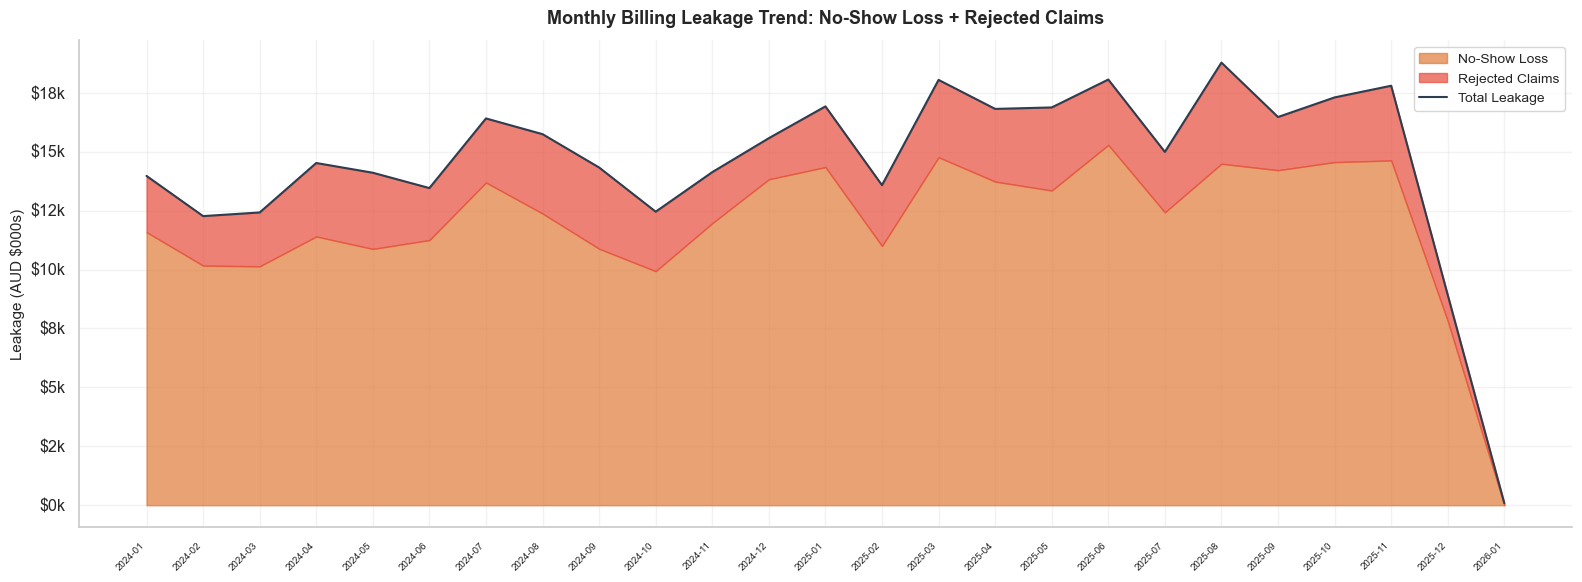

Saved: reports/leakage_trend.png


In [11]:
# Monthly no-show loss
no_show_monthly = (
    appt[appt['status'] == 'no_show']
    .groupby('month_str')['scheduled_fee']
    .sum()
    .reset_index()
    .rename(columns={'scheduled_fee': 'no_show_loss'})
)

# Monthly rejected claims (Medicare + Private combined)
reject_mask = claims['claim_status'].str.lower().str.strip().isin(['rejected', 'partial'])
rejected_monthly = (
    claims[reject_mask]
    .groupby('month_str')['rejected_amount']
    .sum()
    .reset_index()
    .rename(columns={'rejected_amount': 'rejected_claims'})
)

# Merge on month_str
all_months = sorted(set(appt['month_str'].unique()) | set(claims['month_str'].unique()))
trend_df   = pd.DataFrame({'month_str': all_months})
trend_df   = trend_df.merge(no_show_monthly,  on='month_str', how='left')
trend_df   = trend_df.merge(rejected_monthly, on='month_str', how='left')
trend_df[['no_show_loss', 'rejected_claims']] = trend_df[['no_show_loss', 'rejected_claims']].fillna(0)
trend_df['total_leakage_monthly'] = trend_df['no_show_loss'] + trend_df['rejected_claims']

fig, ax = plt.subplots(figsize=(16, 6))
months_list = trend_df['month_str'].tolist()
x = range(len(months_list))

ax.fill_between(x, trend_df['no_show_loss'] / 1000, alpha=0.7,
                color='#e07b39', label='No-Show Loss')
ax.fill_between(x,
                trend_df['no_show_loss'] / 1000,
                trend_df['total_leakage_monthly'] / 1000,
                alpha=0.7, color='#e74c3c', label='Rejected Claims')

ax.plot(x, trend_df['total_leakage_monthly'] / 1000,
        color='#2c3e50', linewidth=1.5, label='Total Leakage')

ax.set_xticks(list(x))
ax.set_xticklabels(months_list, rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
ax.set_ylabel('Leakage (AUD $000s)', fontsize=11)
ax.set_title('Monthly Billing Leakage Trend: No-Show Loss + Rejected Claims',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
sns.despine()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/leakage_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/leakage_trend.png')

---
## 5. Claim Rejection Rate by Month and Type

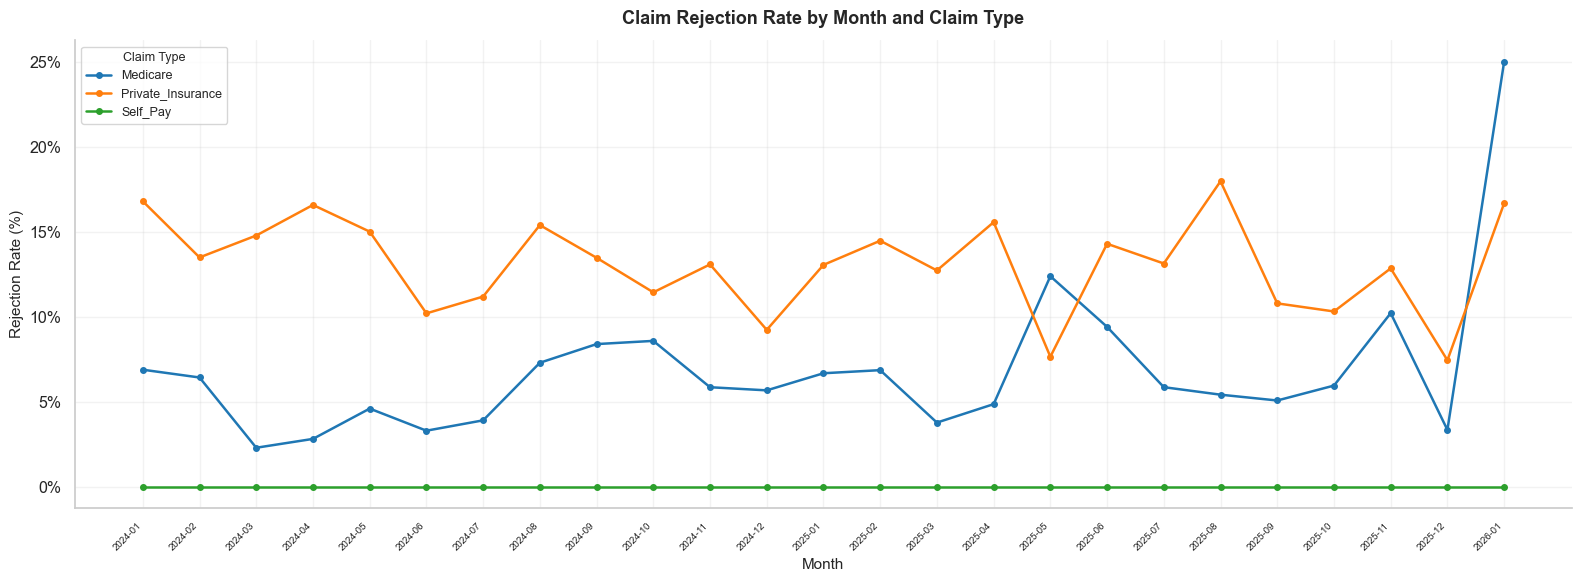

Saved: reports/claim_rejection_trend.png


In [13]:
claims['is_rejected'] = claims['claim_status'].str.lower().str.strip().isin(['rejected', 'partial'])

rejection_by_type = (
    claims.groupby(['month_str', 'claim_type'])
    .agg(
        total_claims   = ('claim_id',    'count'),
        rejected_count = ('is_rejected', 'sum'),
    )
    .reset_index()
)
rejection_by_type['rejection_rate'] = (
    rejection_by_type['rejected_count'] / rejection_by_type['total_claims'] * 100
)

claim_types = rejection_by_type['claim_type'].unique()
type_palette = sns.color_palette('tab10', len(claim_types))

fig, ax = plt.subplots(figsize=(16, 6))

for ct, col in zip(claim_types, type_palette):
    subset = rejection_by_type[rejection_by_type['claim_type'] == ct].sort_values('month_str')
    ax.plot(
        subset['month_str'], subset['rejection_rate'],
        marker='o', markersize=4, linewidth=1.8,
        label=ct, color=col
    )

months_rej = sorted(rejection_by_type['month_str'].unique())
ax.set_xticks(range(len(months_rej)))
ax.set_xticklabels(months_rej, rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylabel('Rejection Rate (%)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Claim Rejection Rate by Month and Claim Type',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Claim Type', fontsize=9, title_fontsize=9)
ax.grid(True, alpha=0.25)
sns.despine()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/claim_rejection_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/claim_rejection_trend.png')

---
## 6. Recovery Scenarios

=== RECOVERY SCENARIOS ===
scenario                      Aggressive\n(75% fix)  Conservative\n(20% fix)  Moderate\n(50% fix)
bucket                                                                                           
Bulk Bill\nErosion                         6,093.81                 1,625.02             4,062.54
Medicare\nRejections                      16,246.54                 4,332.41            10,831.02
No-Show\nLoss                            224,099.44                59,759.85           149,399.62
Private Ins.\nReject/Partial              32,755.60                 8,734.83            21,837.07
Self-Pay\nDefaults                        31,778.19                 8,474.18            21,185.46

Total Recovery:
  Aggressive (75% fix): $310,974
  Conservative (20% fix): $82,926
  Moderate (50% fix): $207,316


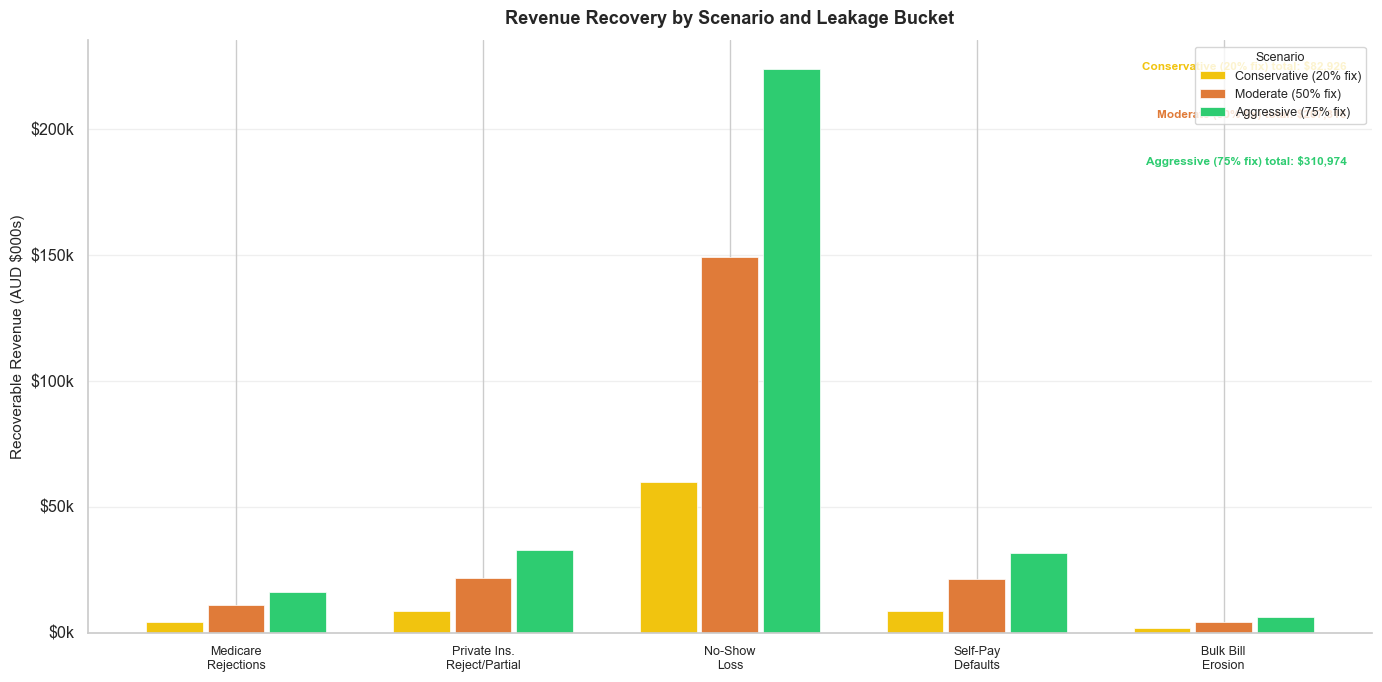

Saved: reports/recovery_scenarios.png


In [15]:
scenarios = {
    'Conservative\n(20% fix)': 0.20,
    'Moderate\n(50% fix)':     0.50,
    'Aggressive\n(75% fix)':   0.75,
}

bucket_names_short = [
    'Medicare\nRejections',
    'Private Ins.\nReject/Partial',
    'No-Show\nLoss',
    'Self-Pay\nDefaults',
    'Bulk Bill\nErosion',
]
bucket_values = list(buckets.values())

recovery_rows = []
for scenario, rate in scenarios.items():
    for bname, bval in zip(bucket_names_short, bucket_values):
        recovery_rows.append({
            'scenario':  scenario,
            'bucket':    bname,
            'recovery':  bval * rate,
        })
recovery_df = pd.DataFrame(recovery_rows)

# Also compute total per scenario for annotation
scenario_totals = recovery_df.groupby('scenario')['recovery'].sum()

print('=== RECOVERY SCENARIOS ===')
pivot = recovery_df.pivot_table(index='bucket', columns='scenario', values='recovery', aggfunc='sum')
print(pivot.to_string())
print(f'\nTotal Recovery:')
for sc, tot in scenario_totals.items():
    sc_clean = sc.replace('\n', ' ')
    print(f'  {sc_clean}: ${tot:,.0f}')

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

scenario_list = list(scenarios.keys())
n_scenarios   = len(scenario_list)
n_buckets     = len(bucket_names_short)
x             = np.arange(n_buckets)
width         = 0.25
bar_colors    = ['#f1c40f', '#e07b39', '#2ecc71']

for i, (sc, col) in enumerate(zip(scenario_list, bar_colors)):
    vals = [recovery_df[(recovery_df['scenario'] == sc) & (recovery_df['bucket'] == b)]['recovery'].sum()
            for b in bucket_names_short]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, [v / 1000 for v in vals],
                  width=width - 0.02, label=sc.replace('\n', ' '),
                  color=col, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(bucket_names_short, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
ax.set_ylabel('Recoverable Revenue (AUD $000s)', fontsize=11)
ax.set_title('Revenue Recovery by Scenario and Leakage Bucket',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Scenario', fontsize=9, title_fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine()

# Annotate total per scenario at top right
for i, (sc, rate) in enumerate(scenarios.items()):
    tot = total_leakage * rate
    ax.text(0.98, 0.95 - i * 0.08,
            f'{sc.replace(chr(10), " ")} total: ${tot:,.0f}',
            transform=ax.transAxes, ha='right', fontsize=8.5,
            color=bar_colors[i], fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/recovery_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/recovery_scenarios.png')

---
## 7. Save Outputs

In [17]:
# Save leakage summary
leakage_path = f'{PROC_DIR}/leakage_summary.csv'
leakage_df.to_csv(leakage_path, index=False)
print(f'Saved: {leakage_path}')

# Save recovery scenarios
recovery_pivot = recovery_df.pivot_table(index='bucket', columns='scenario', values='recovery', aggfunc='sum')
recovery_pivot.columns = [c.replace('\n', ' ') for c in recovery_pivot.columns]
recovery_pivot.reset_index(inplace=True)
recovery_path = f'{PROC_DIR}/recovery_scenarios.csv'
recovery_pivot.to_csv(recovery_path, index=False)
print(f'Saved: {recovery_path}')

Saved: ../data/processed/leakage_summary.csv
Saved: ../data/processed/recovery_scenarios.csv


---
## 8. Executive Summary

In [19]:
moderate_recovery = total_leakage * 0.50
leakage_pct       = total_leakage / gross_revenue * 100 if gross_revenue > 0 else 0

print('=' * 60)
print('  EXECUTIVE SUMMARY — Billing Leakage Analysis')
print('  HealthFirst Australia | Revenue Intelligence Platform')
print('=' * 60)
print(f'  Gross Revenue (completed appointments) : ${gross_revenue:>14,.2f}')
print(f'  Total Billing Leakage                  : ${total_leakage:>14,.2f}')
print(f'  Leakage as % of Gross Revenue          : {leakage_pct:>13.1f}%')
print(f'  Realized Revenue (after leakage)       : ${realized:>14,.2f}')
print()
print('  Leakage by Bucket:')
for _, row in leakage_df.iterrows():
    print(f"    {row['bucket']:<40} ${row['leakage_amount']:>12,.0f}  ({row['pct_of_gross']:.1f}%)")
print()
print('  Recovery Scenarios:')
for sc, rate in scenarios.items():
    amt = total_leakage * rate
    sc_label = sc.replace('\n', ' ')
    print(f'    {sc_label:<30} ${amt:>12,.0f}')
print()
print(f'  RECOMMENDED ACTION (Moderate 50% fix)  : ${moderate_recovery:>14,.2f}')
print(f'  This would improve realized revenue by : {moderate_recovery/gross_revenue*100:.1f}%')
print('=' * 60)

  EXECUTIVE SUMMARY — Billing Leakage Analysis
  HealthFirst Australia | Revenue Intelligence Platform
  Gross Revenue (completed appointments) : $  1,547,162.07
  Total Billing Leakage                  : $    414,631.44
  Leakage as % of Gross Revenue          :          26.8%
  Realized Revenue (after leakage)       : $  1,132,530.63

  Leakage by Bucket:
    Bucket 3: No-Show Loss                   $     298,799  (19.3%)
    Bucket 2: Private Ins. Reject/Partial    $      43,674  (2.8%)
    Bucket 4: Self-Pay Defaults              $      42,371  (2.7%)
    Bucket 1: Medicare Rejections            $      21,662  (1.4%)
    Bucket 5: Bulk Bill Erosion              $       8,125  (0.5%)

  Recovery Scenarios:
    Conservative (20% fix)         $      82,926
    Moderate (50% fix)             $     207,316
    Aggressive (75% fix)           $     310,974

  RECOMMENDED ACTION (Moderate 50% fix)  : $    207,315.72
  This would improve realized revenue by : 13.4%
